In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2

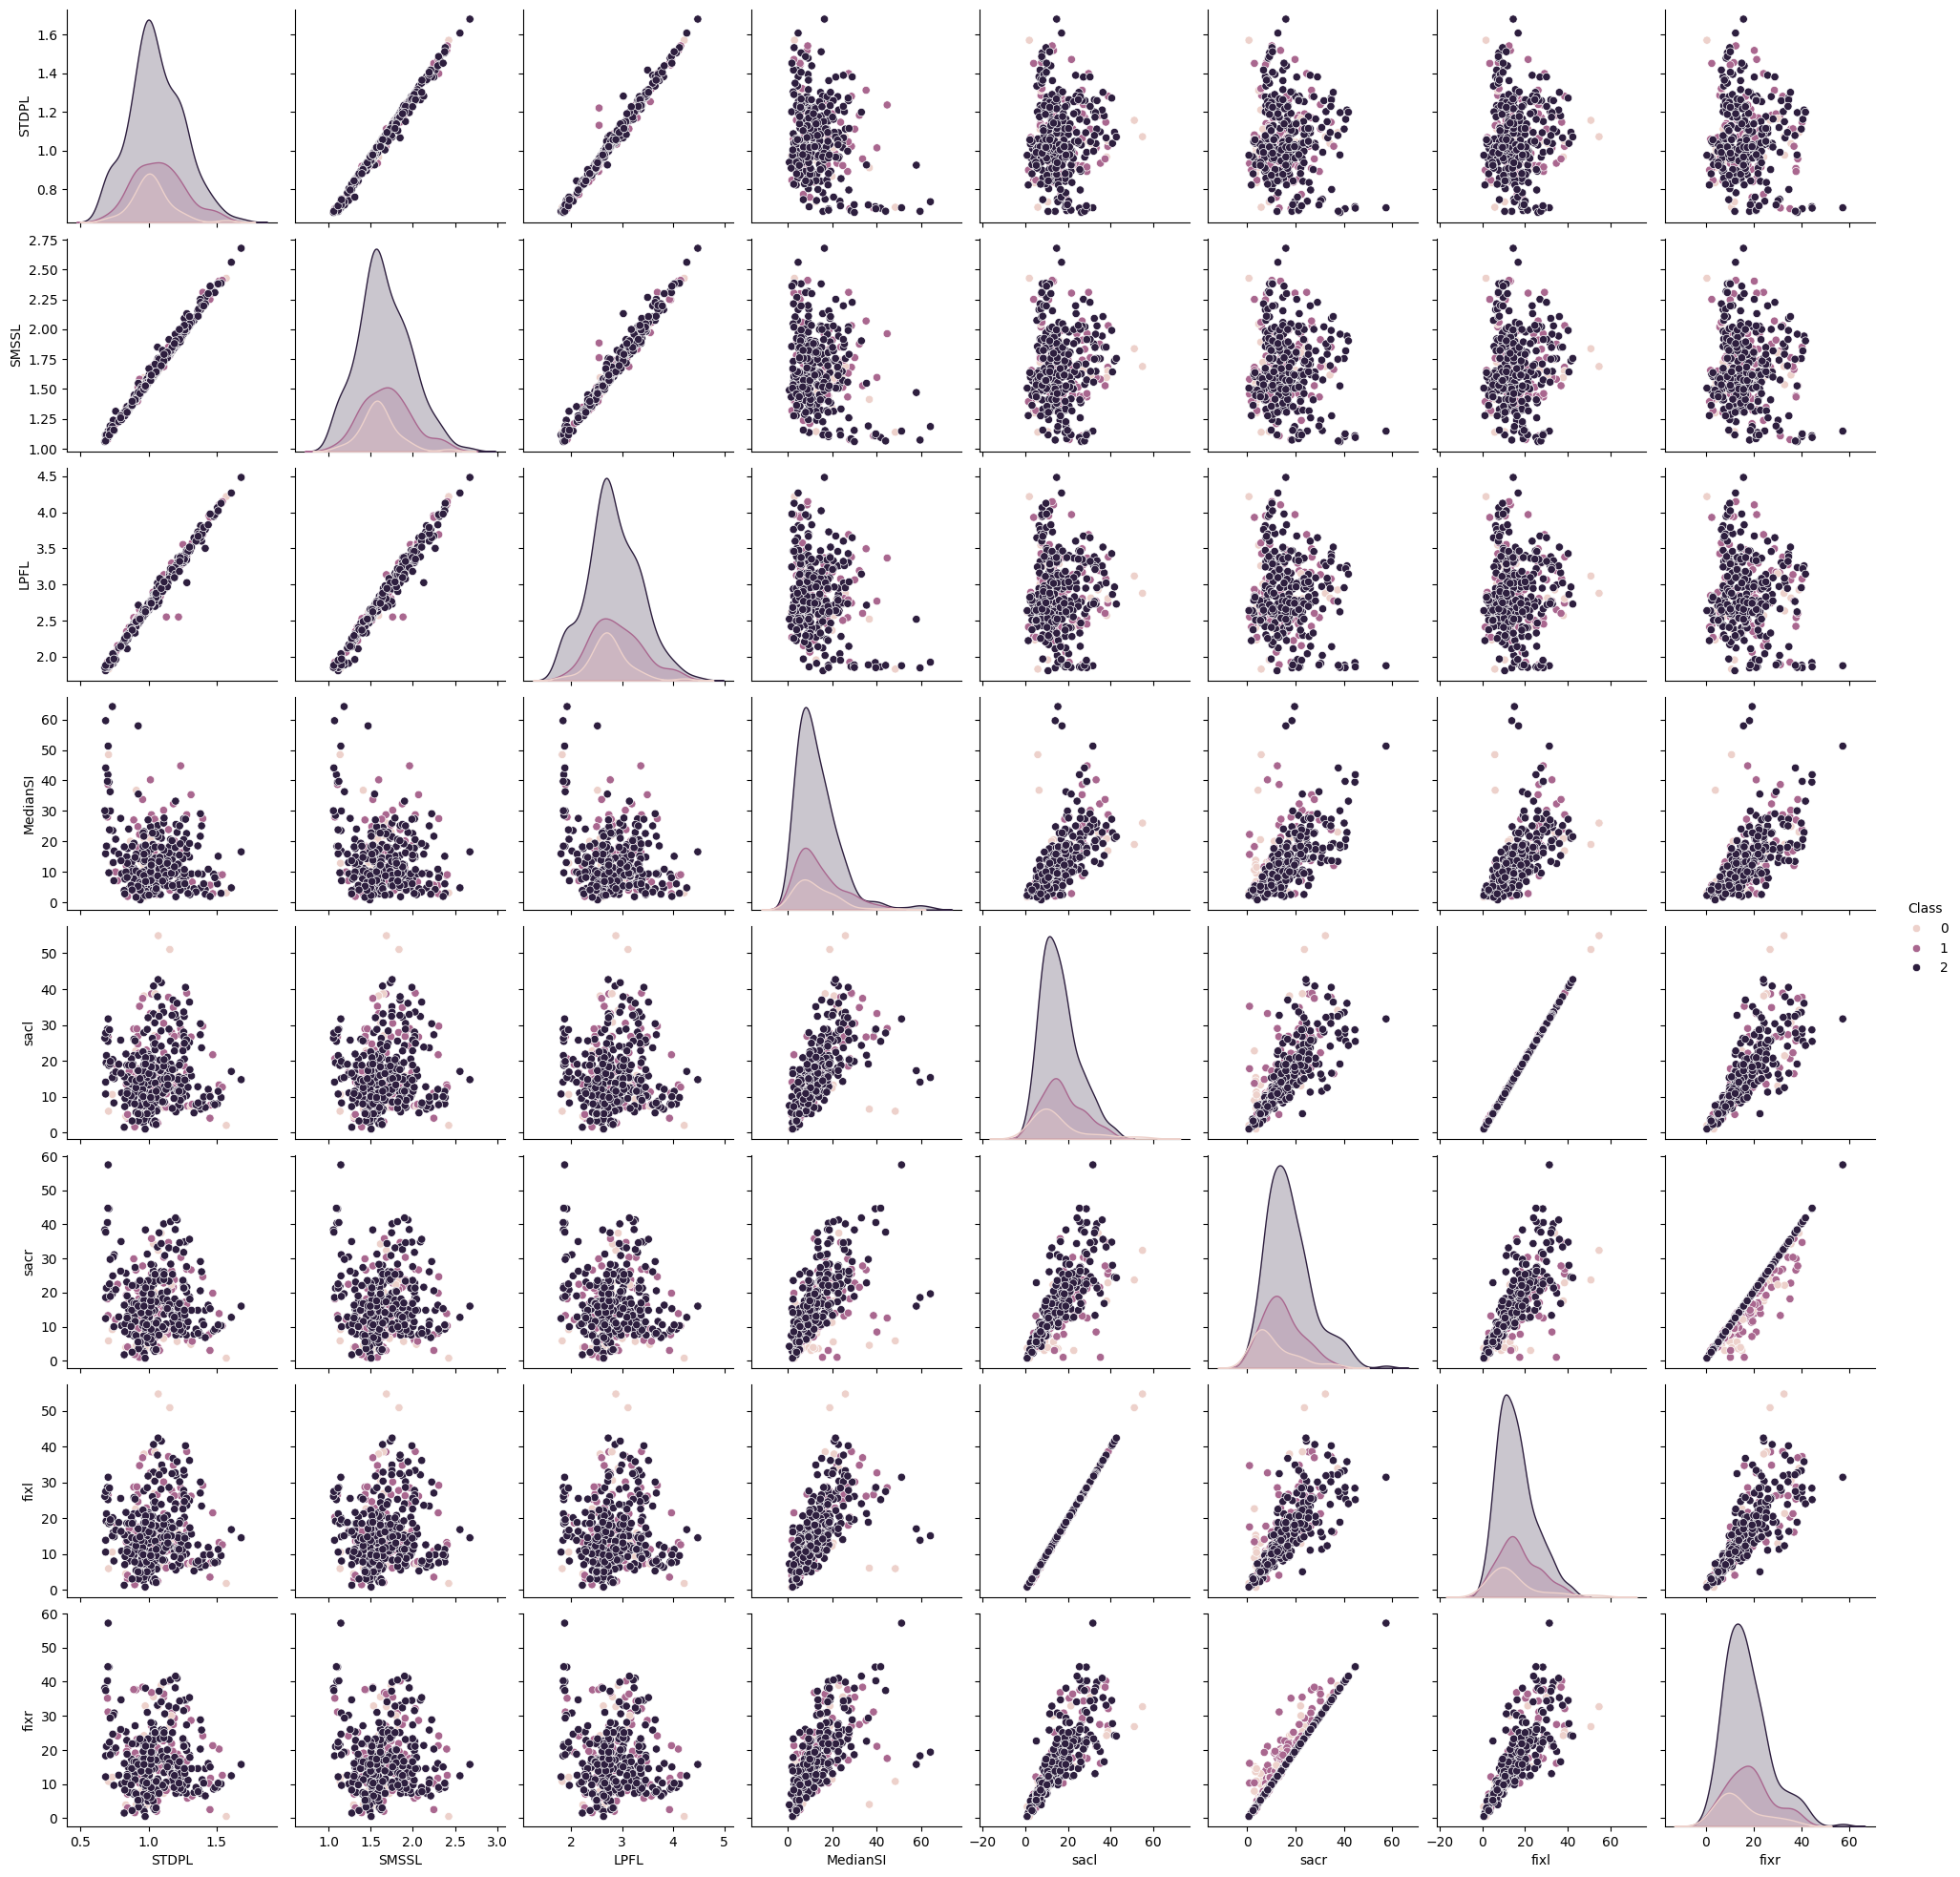

In [2]:

# Load Training Dataset

df = pd.read_csv("traindata_2sec.csv")

sns.pairplot(df, hue="Class")
plt.show()


In [3]:
# Prepare Binary Dataset

df_class0 = df[df["Class"] == 0]
df_class1 = df[df["Class"] == 1]

dataset = pd.concat([df_class0, df_class1])

X_train = dataset.iloc[:, 0:8].values
y_train = dataset.iloc[:, 8].values

In [4]:
# Feature Scaling

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

In [5]:
# Build ANN

model = Sequential()

model.add(
    Dense(
        160,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_dim=8,
    )
)

model.add(
    Dense(
        80,
        activation="relu",
        kernel_regularizer=l2(0.001),
    )
)

model.add(Dense(1, activation="sigmoid"))

c:\Programs DevNiru2704\ML lab\ml\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compile Model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Train Model

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=1,
    verbose=1
)

model.save("binary_model.h5")

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6719 - loss: 0.7137
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6676 
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6606
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6550
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6719 - loss: 0.6437
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6797 - loss: 0.6413 
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6396
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 0.6330 
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 0.6307
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6719 - loss: 0.6325
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 0.6235
Epoch 12/100
128/128 ━━━━━━━━━━━━━━━━━

In [8]:
# Load Test Dataset

test_df = pd.read_csv("testdata_2sec.csv")

test_df = test_df[test_df["Class"].isin([0, 1])]

X_test = test_df.iloc[:, 0:8].values
y_test = test_df.iloc[:, 8].values

X_test = scaler.transform(X_test)

In [9]:
# Prediction

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [10]:
# Accuracy

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

accuracy = ((TP + TN) / (TP + TN + FP + FN)) * 100

print("Confusion Matrix:")
print(cm)

print(f"\nTP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

print(f"\nAccuracy = {accuracy:.2f}%")

Confusion Matrix:
[[ 8  5]
 [ 1 12]]

TP = 12
TN = 8
FP = 5
FN = 1

Accuracy = 76.92%
